# Employee Attrition Analysis with XGBoost

In [26]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


In [27]:
df = pd.read_csv("HR_Employee_Attrition.csv")

df.head()


,Employee_ID,Age,Gender,Department,JobRole,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,41,Female,Sales,Sales Executive,Yes,Travel_Rarely,1102,1,2,...,1,80,0,8,0,1,6,4,0,5
1,2,49,Male,Research & Development,Research Scientist,No,Travel_Frequently,279,8,1,...,4,80,1,10,3,3,10,7,1,7
2,4,37,Male,Research & Development,Laboratory Technician,Yes,Travel_Rarely,1373,2,2,...,2,80,0,7,3,3,0,0,0,0
3,5,33,Female,Research & Development,Research Scientist,No,Travel_Frequently,1392,3,4,...,3,80,0,8,3,3,8,7,3,0
4,7,27,Male,Research & Development,Laboratory Technician,No,Travel_Rarely,591,2,1,...,4,80,1,6,3,3,2,2,2,2


In [28]:

print(df.shape)

print(df.info())


(1470, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee_ID               1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Gender                    1470 non-null   object
 3   Department                1470 non-null   object
 4   JobRole                   1470 non-null   object
 5   Attrition                 1470 non-null   object
 6   BusinessTravel            1470 non-null   object
 7   DailyRate                 1470 non-null   int64 
 8   DistanceFromHome          1470 non-null   int64 
 9   Education                 1470 non-null   int64 
 10  EducationField            1470 non-null   object
 11  EmployeeCount             1470 non-null   int64 
 12  EnvironmentSatisfaction   1470 non-null   int64 
 13  HourlyRate                1470 non-null   int64 
 14  JobInvolvemen

In [29]:
df.isnull().sum()


Employee_ID                 0
Age                         0
Gender                      0
Department                  0
JobRole                     0
Attrition                   0
BusinessTravel              0
DailyRate                   0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithC

In [30]:
df["Attrition"].value_counts()


Attrition
No     1233
Yes     237
Name: count, dtype: int64

# Additional EDA Charts

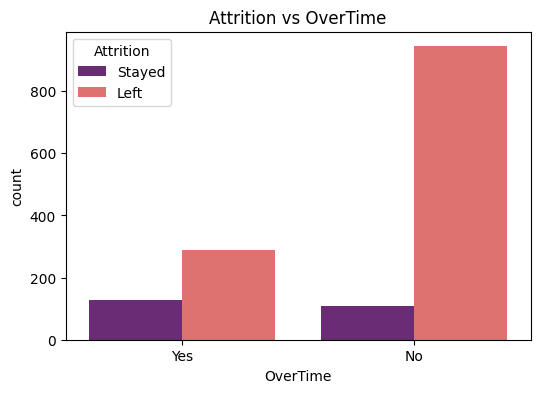

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="OverTime",
    hue="Attrition",
    data=df,
    palette="magma"
)

plt.title("Attrition vs OverTime")

plt.legend(
    title="Attrition",
    labels=["Stayed", "Left"]
)

plt.show()


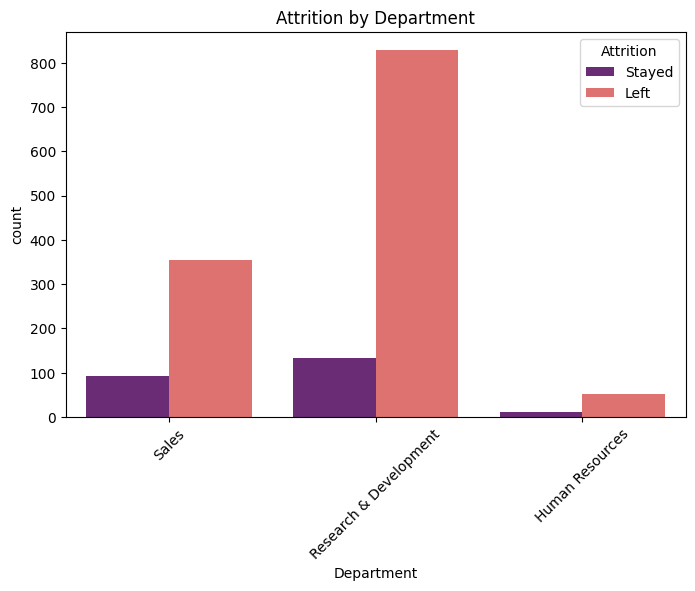

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df,
    palette="magma"
)

plt.title("Attrition by Department")

plt.xticks(rotation=45)

plt.legend(
    title="Attrition",
    labels=["Stayed", "Left"]
)

plt.show()


C:\Users\LapTop\AppData\Local\Temp\ipykernel_27268\4124326765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


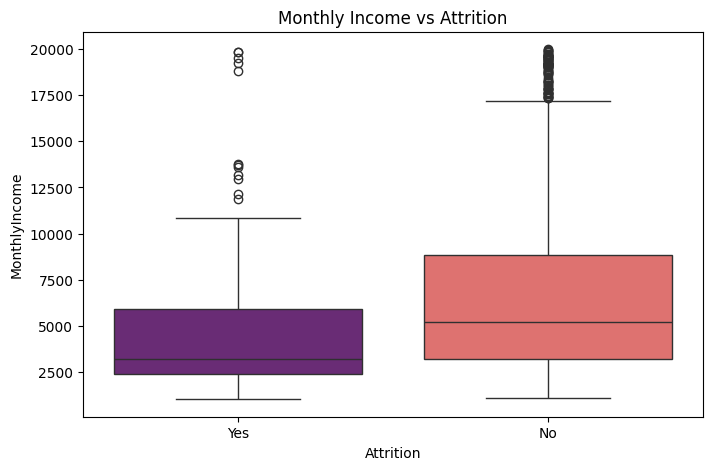

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df,
    palette="magma"
)

plt.title("Monthly Income vs Attrition")

plt.show()


C:\Users\LapTop\AppData\Local\Temp\ipykernel_27268\2169387346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


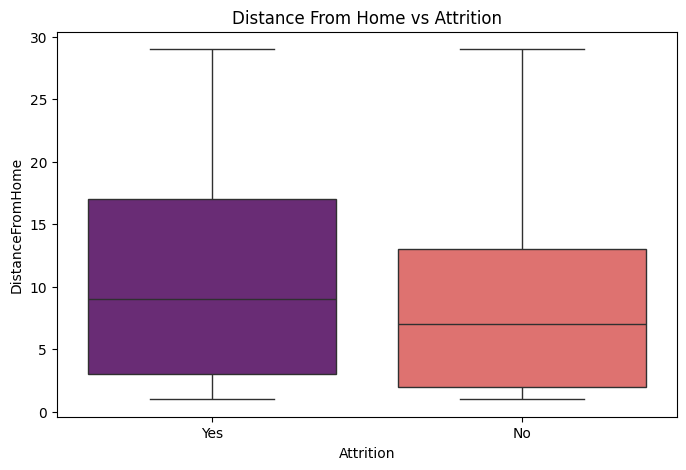

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="DistanceFromHome",
    data=df,
    palette="magma"
)

plt.title("Distance From Home vs Attrition")

plt.show()


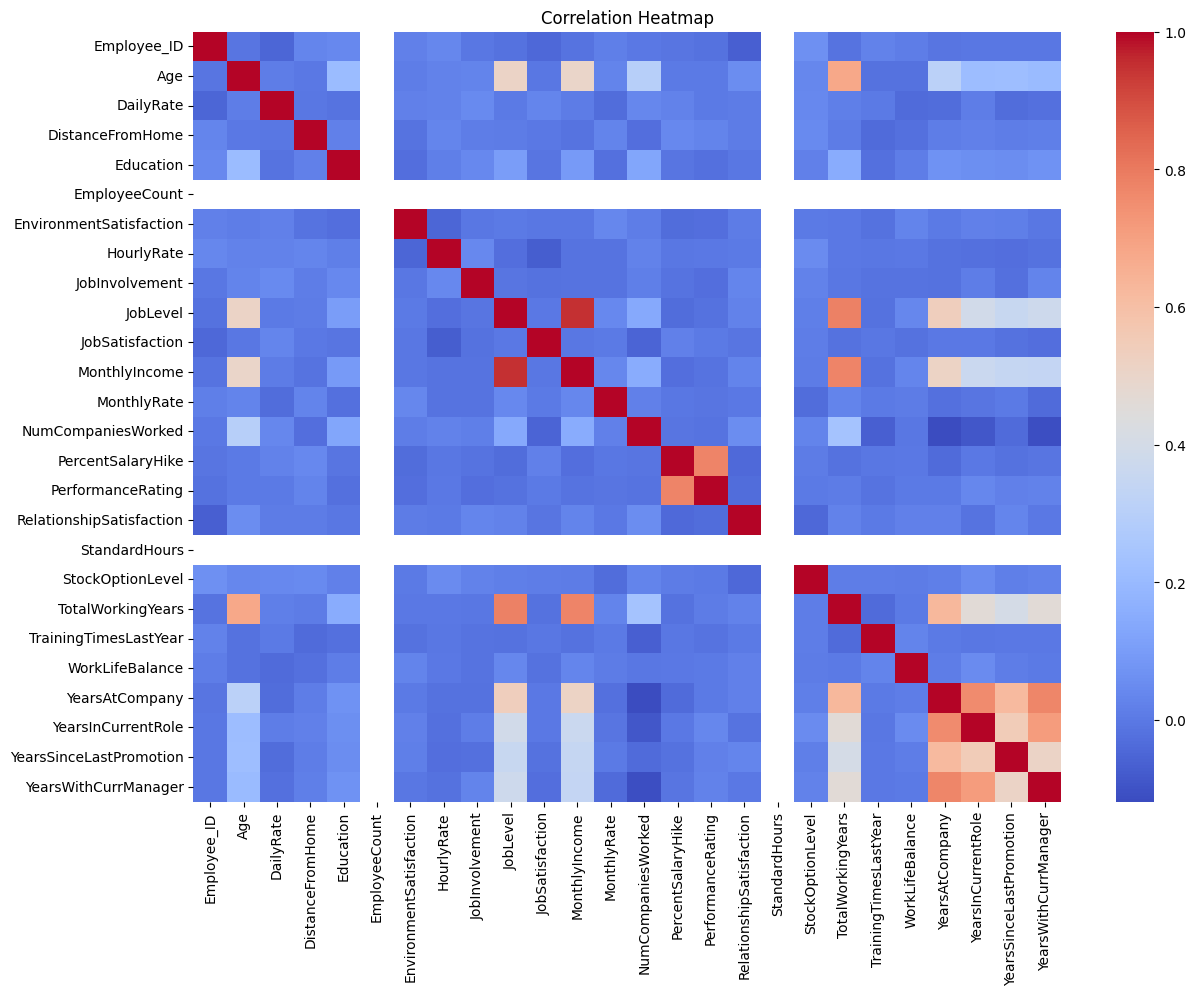

In [35]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


C:\Users\LapTop\AppData\Local\Temp\ipykernel_27268\2577014364.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


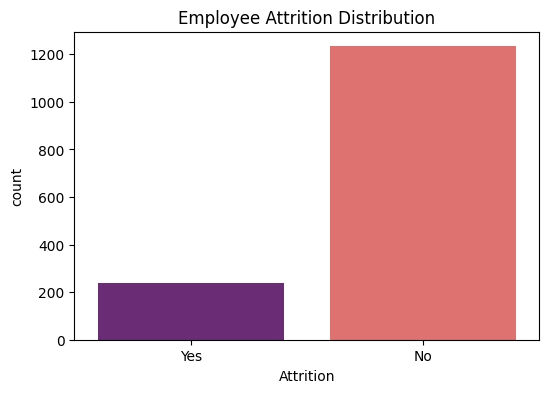

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition",
    data=df,
    palette="magma"
)

plt.title("Employee Attrition Distribution")

plt.show()


In [37]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].value_counts()


Attrition
0    1233
1     237
Name: count, dtype: int64

In [38]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]


In [39]:
X = X.drop([
    "EmployeeCount",
    "StandardHours",
    "Employee_ID"
], axis=1, errors="ignore")

X.head()


,Age,Gender,Department,JobRole,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Female,Sales,Sales Executive,Travel_Rarely,1102,1,2,Life Sciences,2,...,3,1,0,8,0,1,6,4,0,5
1,49,Male,Research & Development,Research Scientist,Travel_Frequently,279,8,1,Life Sciences,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Male,Research & Development,Laboratory Technician,Travel_Rarely,1373,2,2,Other,4,...,3,2,0,7,3,3,0,0,0,0
3,33,Female,Research & Development,Research Scientist,Travel_Frequently,1392,3,4,Life Sciences,4,...,3,3,0,8,3,3,8,7,3,0
4,27,Male,Research & Development,Laboratory Technician,Travel_Rarely,591,2,1,Medical,1,...,3,4,1,6,3,3,2,2,2,2


In [40]:
le = LabelEncoder()

for col in X.select_dtypes(include=["object"]).columns:
    X[col] = le.fit_transform(X[col])

X.head()


,Age,Gender,Department,JobRole,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,0,2,7,2,1102,1,2,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,1,1,6,1,279,8,1,1,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,1,2,2,1373,2,2,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,6,1,1392,3,4,1,4,...,3,3,0,8,3,3,8,7,3,0
4,27,1,1,2,2,591,2,1,3,1,...,3,4,1,6,3,3,2,2,2,2


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(1176, 30)
(294, 30)


In [42]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [43]:
xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")


XGBoost Model Trained Successfully


In [44]:
xgb_pred = xgb_model.predict(X_test)

xgb_pred[:10]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [45]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)


XGBoost Accuracy: 0.8809523809523809


In [46]:
print(classification_report(y_test, xgb_pred))


              precision    recall  f1-score   support

           0       0.90      0.98      0.93       255
           1       0.62      0.26      0.36        39

    accuracy                           0.88       294
   macro avg       0.76      0.62      0.65       294
weighted avg       0.86      0.88      0.86       294



In [47]:
cm = confusion_matrix(y_test, xgb_pred)

print(cm)


[[249   6]
 [ 29  10]]


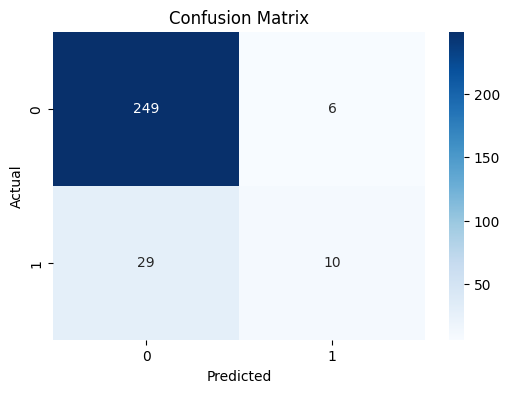

In [48]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [49]:
importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

importance_xgb.head(10)


,Feature,Importance
12,JobLevel,0.129935
18,OverTime,0.105018
2,Department,0.073961
22,StockOptionLevel,0.050080
23,TotalWorkingYears,0.043270
14,MaritalStatus,0.041388
15,MonthlyIncome,0.036586
17,NumCompaniesWorked,0.031689
11,JobInvolvement,0.030713
26,YearsAtCompany,0.029878


C:\Users\LapTop\AppData\Local\Temp\ipykernel_27268\1009034753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


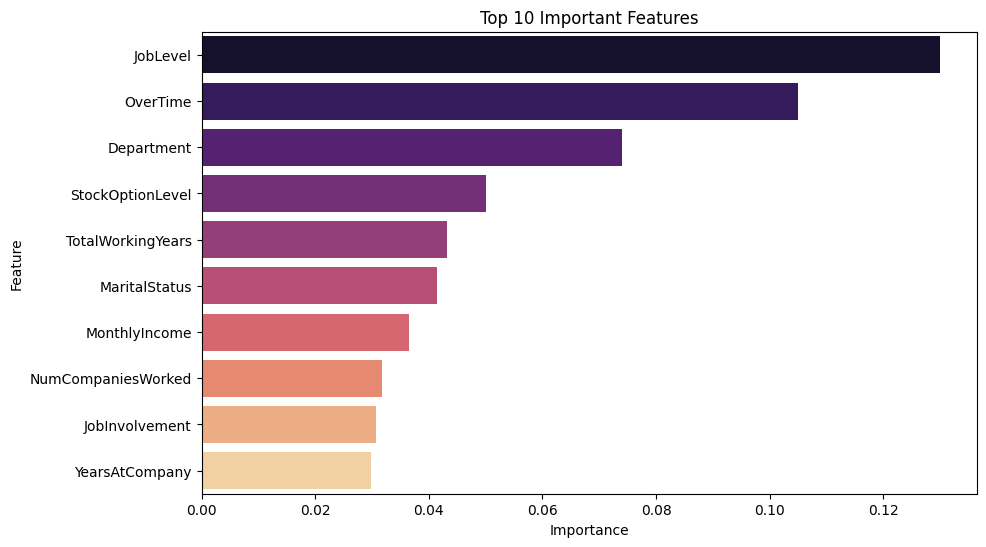

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_xgb.head(10),
    palette="magma"
)

plt.title("Top 10 Important Features")

plt.show()


In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

df = pd.read_csv("HR_Employee_Attrition.csv")

# Convert target
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

features = [
    "Age",
    "BusinessTravel",
    "Department",
    "DistanceFromHome",
    "EducationField",
    "JobRole",
    "MonthlyIncome",
    "OverTime",
    "TotalWorkingYears",
    "YearsAtCompany",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance"
]

X = df[features]
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)


pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)


pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

joblib.dump(
    pipeline,
    r"C:\Users\LapTop\Downloads\depi employee\employee\xgb_attrition_pipeline.pkl"
)

print("Model saved successfully")

XGBoost Accuracy: 0.8401360544217688
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.50      0.23      0.32        47

    accuracy                           0.84       294
   macro avg       0.68      0.59      0.61       294
weighted avg       0.81      0.84      0.82       294

[[236  11]
 [ 36  11]]
Model saved successfully
